In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import tarfile
import nibabel as nib
import matplotlib.pyplot as plt
import random

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from scipy.ndimage import rotate

In [ ]:
drive_path = "/content/drive/MyDrive/Colab Notebooks/"
tar_files = glob.glob(drive_path + "*.tar") + glob.glob(drive_path + "*.tar.gz") + glob.glob(drive_path + "*.zip")
print("Found archive files:")
for f in tar_files:
    size_gb = os.path.getsize(f) / (1024**3)
    print(f"  {os.path.basename(f)} ({size_gb:.1f} GB)")

Found archive files:
  BraTS2021_Training_Data.tar (12.5 GB)


In [ ]:

tar_name = "BraTS2021_Training_Data.tar"
tar_path = os.path.join(drive_path, tar_name)

print(f"Copying {tar_name} to local...")
!cp "{tar_path}" /content/   #copy file from google drive to google colab local storage
print("Copy done")

Copying BraTS2021_Training_Data.tar to local...
Copy done


In [ ]:
import zipfile
import tarfile
import os

# Paths
drive_path = "/content/"
tar_archive_path = os.path.join(drive_path, "BraTS2021_Training_Data.tar")
extract_dir = "/content/brats_dataset/"

# Creating extraction directory
os.makedirs(extract_dir, exist_ok=True)

print("=" * 60)
print("EXTRACTING DATASET")
print("=" * 60)

# Extract the main tar file
print("\n[1/3] Extracting main tar file (13GB)... Starting with a single file (tar.gz or tar) means direct extraction...")
with tarfile.open(tar_archive_path, 'r') as tar_ref:
    members = tar_ref.getmembers()
    total = len(members)
    for i, member in enumerate(members):
        tar_ref.extract(member, path=extract_dir)
        if (i + 1) % 500 == 0: # Print progress less frequently for large archives
            print(f"  Progress: {i+1}/{total} files ({(i+1)/total*100:.1f}%) -- Current file: {member.name}")
print("  Main tar extraction complete!")

# Find all tar files (if any are nested inside the first tar)
print("\n[2/3] Finding nested tar files (if any)...")
nested_tar_files = []
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        if f.endswith('.tar') and os.path.join(root,f) != tar_archive_path: # Exclude the main archive itself
            nested_tar_files.append(os.path.join(root, f))
print(f"  Found {len(nested_tar_files)} nested tar files: {[os.path.basename(f) for f in nested_tar_files]}")

#Extract each nested tar file
if nested_tar_files:
    print("\n[3/3] Extracting nested tar files...")
    for current_tar_path in nested_tar_files:
        print(f"  Extracting {os.path.basename(current_tar_path)}...")
        tar_dir = os.path.dirname(current_tar_path)
        with tarfile.open(current_tar_path, 'r') as tar:
            members = tar.getmembers()
            for i, member in enumerate(members):
                tar.extract(member, path=tar_dir)
                if (i + 1) % 500 == 0:
                    print(f"    Progress: {i+1}/{len(members)} files")
        print(f"  Completed {os.path.basename(current_tar_path)}")
        # Deleting tar files to save space on the colab disk because during execution i hit the limit 1-2 times so just to be sure that doesnt persist
        os.remove(current_tar_path)
        print(f"  Deleted {os.path.basename(current_tar_path)}")
else:
    print("\n[3/3] No nested tar files found to extract.")

print("\n" + "=" * 60)
print("EXTRACTION COMPLETE!")
print("=" * 60)

# Verifying results
print("\nVerifying extracted files...")
nifti_files = []
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        if f.endswith('.nii.gz'):
            nifti_files.append(f)

print(f"\nTotal NIfTI files found: {len(nifti_files)}")

# Get unique patients
patients = set()
for f in nifti_files:
    parts = f.split('_')
    if len(parts) >= 2:
        patients.add(f"{parts[0]}_{parts[1]}")

print(f"Total unique patients: {len(patients)}")

print("\nSample NIfTI files:")
for f in nifti_files[:10]:
    print(f"  {f}")

print(f"\nData saved to: {extract_dir}")

EXTRACTING DATASET

[1/3] Extracting main tar file (13GB)... Starting with a single file (tar.gz or tar) means direct extraction...


/tmp/ipykernel_1342/3329845700.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extract(member, path=extract_dir)


  Progress: 500/7508 files (6.7%) -- Current file: ./BraTS2021_00117/BraTS2021_00117_t2.nii.gz
  Progress: 1000/7508 files (13.3%) -- Current file: ./BraTS2021_00236/BraTS2021_00236_flair.nii.gz
  Progress: 1500/7508 files (20.0%) -- Current file: ./BraTS2021_00349/BraTS2021_00349_t1.nii.gz
  Progress: 2000/7508 files (26.6%) -- Current file: ./BraTS2021_00477/BraTS2021_00477_t2.nii.gz
  Progress: 2500/7508 files (33.3%) -- Current file: ./BraTS2021_00589/BraTS2021_00589_flair.nii.gz
  Progress: 3000/7508 files (40.0%) -- Current file: ./BraTS2021_00709/BraTS2021_00709_t1.nii.gz
  Progress: 3500/7508 files (46.6%) -- Current file: ./BraTS2021_00839/BraTS2021_00839_t2.nii.gz
  Progress: 4000/7508 files (53.3%) -- Current file: ./BraTS2021_01082/BraTS2021_01082_flair.nii.gz
  Progress: 4500/7508 files (59.9%) -- Current file: ./BraTS2021_01165/BraTS2021_01165_t1.nii.gz
  Progress: 5000/7508 files (66.6%) -- Current file: ./BraTS2021_01248/BraTS2021_01248_t2.nii.gz
  Progress: 5500/7508 f

(240, 240, 155)
(240, 240, 155)


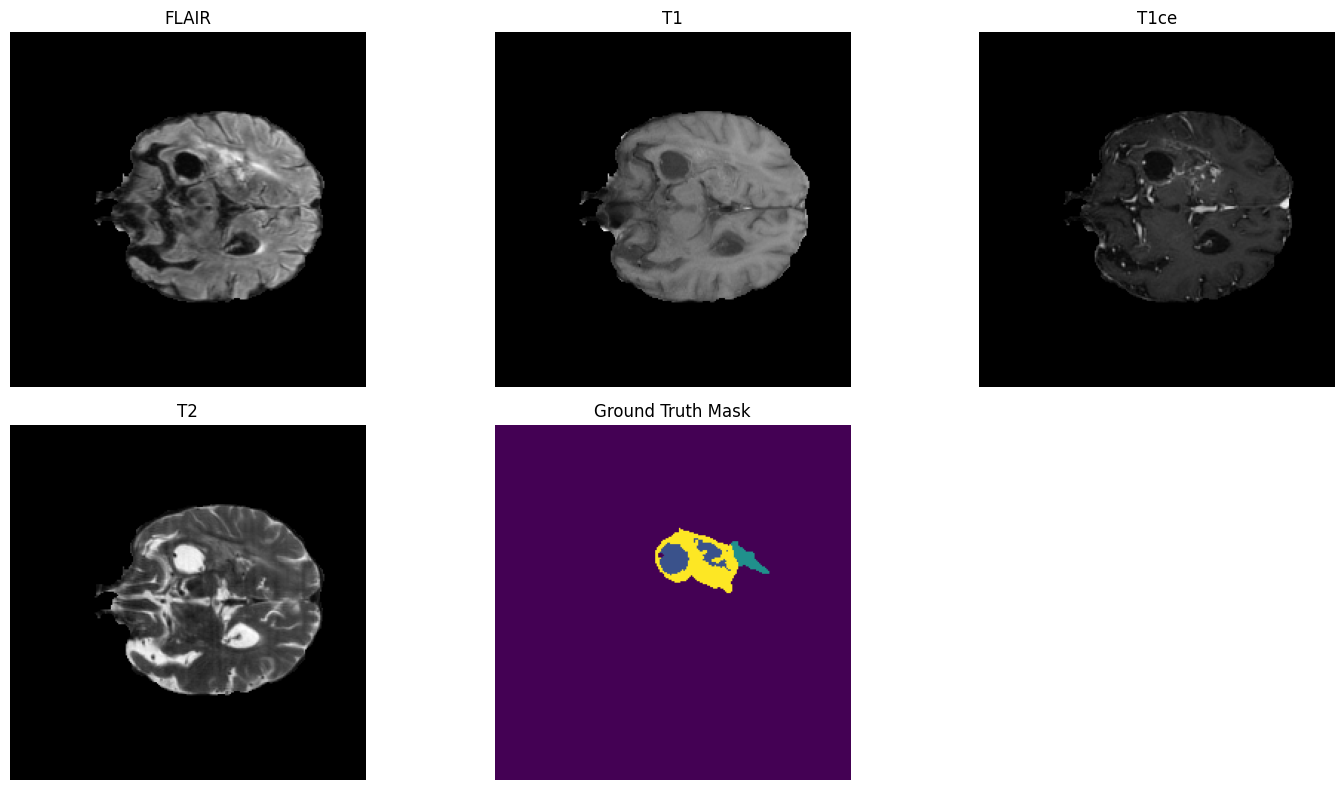

In [ ]:
#Load MRI and mask files


patient_path = "/content/brats_dataset/BraTS2021_00098/"

flair = nib.load(patient_path + "BraTS2021_00098_flair.nii.gz").get_fdata()
t1    = nib.load(patient_path + "BraTS2021_00098_t1.nii.gz").get_fdata()
t1ce  = nib.load(patient_path + "BraTS2021_00098_t1ce.nii.gz").get_fdata()
t2    = nib.load(patient_path + "BraTS2021_00098_t2.nii.gz").get_fdata()

mask  = nib.load(patient_path + "BraTS2021_00098_seg.nii.gz").get_fdata()



print(flair.shape)
print(mask.shape)


slice_idx = 70

flair_slice = flair[:, :, slice_idx]
t1_slice    = t1[:, :, slice_idx]
t1ce_slice  = t1ce[:, :, slice_idx]
t2_slice    = t2[:, :, slice_idx]
mask_slice  = mask[:, :, slice_idx]

#Visualize MRI + Mask

plt.figure(figsize=(15, 8))

# FLAIR
plt.subplot(2, 3, 1)
plt.imshow(flair_slice, cmap='gray')
plt.title("FLAIR")
plt.axis("off")

# T1
plt.subplot(2, 3, 2)
plt.imshow(t1_slice, cmap='gray')
plt.title("T1")
plt.axis("off")

# T1ce
plt.subplot(2, 3, 3)
plt.imshow(t1ce_slice, cmap='gray')
plt.title("T1ce")
plt.axis("off")

# T2
plt.subplot(2, 3, 4)
plt.imshow(t2_slice, cmap='gray')
plt.title("T2")
plt.axis("off")

# Ground truth mask
plt.subplot(2, 3, 5)
plt.imshow(mask_slice)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

# Unet

3D BraTS Dataset

In [ ]:
class BraTSDataset3D(Dataset):  #Dataset is pytorch class
    def __init__(
        self,
        data_dir,
        patch_size=(64, 128, 128),   # Depth/slices, Height, Width
        patches_per_patient=5,       #5 patches per patient
        augment=True,
        tumor_focus=True
    ):
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.patches_per_patient = patches_per_patient
        self.augment = augment
        self.tumor_focus = tumor_focus

        self.patients = []

        for item in os.listdir(data_dir):
            item_path = os.path.join(data_dir, item)
            if os.path.isdir(item_path):
                self.patients.append(item)

        self.patients = sorted(self.patients)

        print(f"Found {len(self.patients)} patients")

    #In PyTorch custom datasets, __len__() is required because DataLoader uses it to know the dataset size.
    def __len__(self):
        return len(self.patients) * self.patches_per_patient

    #Without normalization, the model may train poorly because one modality may dominate others. MRI modalities have different intensity ranges.
    #so we are normalizing the the mri modalities values. x is x → image data / MRI modality
    def normalize(self, x):
        mean = x.mean()
        std = x.std()              #Standard deviation tells how much the pixel/voxel values vary from the mean. Standard deviation tells how much the pixel/voxel values vary from the mean.
        return (x - mean) / (std + 1e-8)

#converts the original BraTS segmentation labels into labels suitable for your model.
    def remap_labels(self, seg):
        seg_processed = np.zeros_like(seg, dtype=np.int64)         #Creates a new mask with the same shape as seg.

        seg_processed[seg == 1] = 1
        seg_processed[seg == 2] = 2
        seg_processed[seg == 4] = 3                                #If you keep label 4, PyTorch can give an error because class 4 does not exist when you have only 4 classes. From 0 to 3

        return seg_processed

        #Each Seg has tumor size, tumor location, shape, condition, fluid, solid, enhancing and on the basis of that seg has label
        """0 = background
        1 = necrotic / non-enhancing tumor
        2 = edema
        3 = enhancing tumor"""

    def pad_if_needed(self, image, seg):
        """
        image shape: [4, H, W, D]
        seg shape  : [H, W, D]
        patch_size : [D, H, W]
        """

        #This function checks whether the MRI volume and segmentation mask are smaller than the required patch size. If any dimension is smaller,
        # it adds zero padding equally before and after that dimension. The same padding is applied to both image and mask so they remain aligned.

        patch_d, patch_h, patch_w = self.patch_size

        _, h, w, d = image.shape


        #number of pixels padding needed, if negative or zero then no need to add padding
        pad_h = max(0, patch_h - h)
        pad_w = max(0, patch_w - w)
        pad_d = max(0, patch_d - d)

        pad_h_before = pad_h // 2
        pad_h_after = pad_h - pad_h_before

        pad_w_before = pad_w // 2
        pad_w_after = pad_w - pad_w_before

        pad_d_before = pad_d // 2
        pad_d_after = pad_d - pad_d_before

        image = np.pad(
            image,
            (
                (0, 0),
                (pad_h_before, pad_h_after),
                (pad_w_before, pad_w_after),
                (pad_d_before, pad_d_after)
            ),
            mode="constant"
        )

        seg = np.pad(
            seg,
            (
                (pad_h_before, pad_h_after),
                (pad_w_before, pad_w_after),
                (pad_d_before, pad_d_after)
            ),
            mode="constant"
        )

        return image, seg

    def get_patch_start(self, center, image_shape):
        """
        center: h, w, d
        image_shape: [4, H, W, D]
        """


        #_ Remove 4 classes
        _, h, w, d = image_shape
        patch_d, patch_h, patch_w = self.patch_size

        center_h, center_w, center_d = center

        #the selected point is the center, we move half patch size backward.
        h_start = center_h - patch_h // 2
        w_start = center_w - patch_w // 2
        d_start = center_d - patch_d // 2

        #This makes sure the patch does not go outside the image boundary.
        #For example, if h_start becomes negative: then it makes it zero.
        #If h_start goes too far near the end, it limits it to:
        #h - patch_h
        #So the patch always stays inside the MRI volume.
        h_start = max(0, min(h_start, h - patch_h))
        w_start = max(0, min(w_start, w - patch_w))
        d_start = max(0, min(d_start, d - patch_d))

        return h_start, w_start, d_start

#This function selects a center point for cropping a 3D patch.
#70% of the time it selects a tumor pixels as the center, and 30% of the time it selects a random point from the whole image.
    def random_patch_center(self, seg):
        h, w, d = seg.shape

        tumor_voxels = np.argwhere(seg > 0)

        #If tumor-focused cropping is enabled
        #AND tumor voxels exist
        #AND random chance is less than 70%
        if self.tumor_focus and len(tumor_voxels) > 0 and random.random() < 0.7:
            center_h, center_w, center_d = tumor_voxels[
                random.randint(0, len(tumor_voxels) - 1)
            ]
        else:
            #select random pixel
            center_h = random.randint(0, h - 1)
            center_w = random.randint(0, w - 1)
            center_d = random.randint(0, d - 1)

        return center_h, center_w, center_d

    def apply_augmentations(self, image, seg):
        """
        image shape after transpose: [4, D, H, W]
        seg shape after transpose  : [D, H, W]
        """

        # Flip depth
        #So both image and mask are flipped in the same direction.
        #This is important because if you flip only the image and not the mask, the tumor location will become wrong.
        if random.random() > 0.5:
            image = np.flip(image, axis=1).copy()
            seg = np.flip(seg, axis=0).copy()

        # Flip height - randomly flips the patch vertically.
        if random.random() > 0.5:
            image = np.flip(image, axis=2).copy()
            seg = np.flip(seg, axis=1).copy()

        # Flip width - randomly flips the patch horizontally.
        if random.random() > 0.5:
            image = np.flip(image, axis=3).copy()
            seg = np.flip(seg, axis=2).copy()

        # Small rotation on H-W plane  applies rotation with 50% chance. The angle is randomly selected between:
        #-10 degrees to +10 degrees
        #So the image may rotate slightly left or right.
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)



            #This rotates each MRI modality separately. image has 4 channels. goes through each channel one by one.
            #Each ch has shape: [D,H,W]. The rotation uses: axes=(1, 2). That means it rotates on the height-width plane.
            #mode="nearest" This is used for MRI images because MRI values are continuous intensity values.
            #means if rotation creates empty border areas, fill them using nearest available values.
            image = np.array([
                rotate(
                    ch,
                    angle,
                    axes=(1, 2),
                    reshape=False,
                    order=1,
                    mode="nearest"
                )
                for ch in image
            ])

            """This function randomly applies flips and small rotations to the 3D MRI patch and its ground truth mask.
            The same transformation is applied to both image and mask so that the tumor position remains correct.
            Image rotation uses linear interpolation because MRI values are continuous, while mask rotation uses nearest-neighbor interpolation to keep class labels as integers.
            """
            #order=0 - to keep labels as exact integers. means nearest-neighbor interpolation. This is correct for segmentation masks.
            seg = rotate(
                seg,
                angle,
                axes=(1, 2),
                reshape=False,
                order=0,
                mode="nearest"
            ).astype(np.int64)

        return image, seg

    def __getitem__(self, idx):
        patient = self.patients[idx // self.patches_per_patient]
        patient_path = os.path.join(self.data_dir, patient)

        flair = nib.load(os.path.join(patient_path, f"{patient}_flair.nii.gz")).get_fdata()
        t1 = nib.load(os.path.join(patient_path, f"{patient}_t1.nii.gz")).get_fdata()
        t1ce = nib.load(os.path.join(patient_path, f"{patient}_t1ce.nii.gz")).get_fdata()
        t2 = nib.load(os.path.join(patient_path, f"{patient}_t2.nii.gz")).get_fdata()
        seg = nib.load(os.path.join(patient_path, f"{patient}_seg.nii.gz")).get_fdata()

        seg = self.remap_labels(seg)

        image = np.stack([flair, t1, t1ce, t2], axis=0)  # [4, H, W, D]

        for c in range(4):
            image[c] = self.normalize(image[c])

        #MRI image and segmentation mask are smaller than the required patch size.
        #it adds zero padding around them.
        #Make image and mask large enough before extracting patches.
        image, seg = self.pad_if_needed(image, seg)

        #it select a center in seg, for selecting area near tumor.
        center = self.random_patch_center(seg)
        #calculates the starting position of the 3D patch.
        h_start, w_start, d_start = self.get_patch_start(center, image.shape)

        #separates the patch size into depth, height, and width values.
        patch_d, patch_h, patch_w = self.patch_size

        #t keeps all four MRI channels and extracts a fixed height, width, and depth region using the calculated start positions and patch size.
        #:; means take all four channels
        image_patch = image[
            :,
            h_start:h_start + patch_h,
            w_start:w_start + patch_w,
            d_start:d_start + patch_d
        ]

        seg_patch = seg[
            h_start:h_start + patch_h,
            w_start:w_start + patch_w,
            d_start:d_start + patch_d
        ]

        # Convert from [4, H, W, D] to [4, D, H, W]-- PyTorch 3D models expect the input in this format
        image_patch = np.transpose(image_patch, (0, 3, 1, 2))

        # Convert from [H, W, D] to [D, H, W]
        seg_patch = np.transpose(seg_patch, (2, 0, 1))

        if self.augment:
            image_patch, seg_patch = self.apply_augmentations(image_patch, seg_patch)

        #converts the NumPy image patch into a PyTorch tensor.
        image_patch = torch.tensor(image_patch.copy()).float()
        seg_patch = torch.tensor(seg_patch.copy()).long()

        return image_patch, seg_patch

SyntaxError: invalid decimal literal (755969431.py, line 185)

Train / Validation / Test Split

In [ ]:
data_dir = "/content/brats_dataset/"

base_dataset = BraTSDataset3D(
    data_dir=data_dir,
    patch_size=(64, 128, 128),
    augment=True,
    tumor_focus=True
)

all_patients = base_dataset.patients[:400]

"""temp_patients is used as a temporary holding group.
Because train_test_split() can split data into only 2 parts at one time, but you need 3 parts:"""

train_patients, temp_patients = train_test_split(
    all_patients,
    test_size=0.20,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Train Patients:", len(train_patients))
print("Validation Patients:", len(val_patients))
print("Test Patients:", len(test_patients))

Found 1251 patients
Train Patients: 320
Validation Patients: 40
Test Patients: 40


Create DataLoaders

In [ ]:
train_dataset_3d = BraTSDataset3D(
    data_dir=data_dir,
    patch_size=(64, 128, 128),
    patches_per_patient=5,
    augment=True,
    tumor_focus=True
)

val_dataset_3d = BraTSDataset3D(
    data_dir=data_dir,
    patch_size=(64, 128, 128),
    patches_per_patient=1,
    augment=False,
    tumor_focus=True
)

test_dataset_3d = BraTSDataset3D(
    data_dir=data_dir,
    patch_size=(64, 128, 128),
    patches_per_patient=1,
    augment=False,
    tumor_focus=True
)

train_dataset_3d.patients = train_patients
val_dataset_3d.patients = val_patients
test_dataset_3d.patients = test_patients

#This is a PyTorch class used to load data in batches.
#We need DataLoader because it makes training easier and organized. But during training, the model needs data in batches.
#So DataLoader converts many individual samples into batches.
"""It automatically does these things:

1. Loads samples from your dataset
2. Creates batches
3. Shuffles data during training
4. Sends data batch by batch to the training loop
5. Makes training cleaner and easier
"""

train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

test_loader_3d = DataLoader(
    test_dataset_3d,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

Found 1251 patients
Found 1251 patients
Found 1251 patients


3D U-Net Model

In [ ]:
#nn.Module is the base class for neural networks in PyTorch.
"""This DoubleConv3D class is a neural network layer/block.
It can contain trainable parameters.
It can be used inside a bigger model.
It can work with optimizer and backpropagation.
So DoubleConv3D becomes a PyTorch model component."""

#super().__init__() This calls the parent class constructor. nn.Module This line is necessary because it properly initializes the PyTorch module.
#Without this line, PyTorch may not correctly register layers and trainable parameters.

"""This code creates one part of the 3D convolution block. First, Conv3d extracts 3D features from the MRI patch.
Then InstanceNorm3d normalizes those features to make training stable.
Finally, LeakyReLU adds non-linearity so the model can learn complex tumor patterns. negative value → keep a very small part"""

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(inplace=True),

            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


#nn.Module means this class inherits from PyTorch’s neural network base class, so PyTorch will treat it as a trainable model.
# init - It runs automatically when you create the model:
#super init - It is important because it allows PyTorch to properly register model layers, parameters, and gradients.
class UNet3D(nn.Module):
    def __init__(self, in_channels=4, n_classes=4):
        super().__init__()

        #So this block converts the 4 MRI input channels into 16 feature maps.
        #This creates the first encoder block of the 3D U-Net.
        self.enc1 = DoubleConv3D(in_channels, 16)
        #This creates a 3D max-pooling layer.
        #It reduces the spatial size by half.
        #Before pooling: [64, 128, 128]
        #After pooling : [32, 64, 64]
        #Because U-Net encoder needs to go deeper and learn larger features.
        #Pooling helps the model understand bigger tumor structures, not only small local details.
        #Smaller feature maps for next encoder layer
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(16, 32)
        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv3D(32, 64)
        self.pool3 = nn.MaxPool3d(2)

        self.enc4 = DoubleConv3D(64, 128)

        self.up3 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv3D(128, 64)

        self.up2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(64, 32)

        self.up1 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(32, 16)

        self.outc = nn.Conv3d(16, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))
        x4 = self.enc4(self.pool3(x3))

        x = self.up3(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        return self.outc(x)

In [ ]:
def dice_loss_3d(pred, target, smooth=1.0, num_classes=4):
    pred_soft = F.softmax(pred, dim=1)
    #This line converts the model output classes scores into probabilities.
    #all outputs are positive and sum to 1.0

    #One-hot encoding converts each class number into a vector where only the correct class position is 1 and all others are 0.
    #This line converts the ground truth mask from class labels into one-hot format, rearranges its dimensions to match the model prediction, and converts it into float.
    target_one_hot = F.one_hot(
        target,
        num_classes=num_classes
    ).permute(0, 4, 1, 2, 3).float()

    dice = 0

    #These lines select prediction and ground truth for one tumor class. The colon means all batch samples, and c means the selected class.
    for c in range(1, num_classes):
        pred_c = pred_soft[:, c]
        target_c = target_one_hot[:, c]

        #pred_c contains predicted probability values for one class, while target_c contains actual ground truth values for the same class in one-hot form.
        #pred_c values are between 0 and 1, and target_c values are 0 or 1.
        intersection = (pred_c * target_c).sum()

        dice_c = (2. * intersection + smooth) / (
            pred_c.sum() + target_c.sum() + smooth
        )

        dice += dice_c

    #dice loss
    return 1 - (dice / (num_classes - 1))

#Cross entropy checks whether each voxel/pixel is classified into the correct classes of tumor.
#It compares predicted class scores with actual class labels.
def combined_loss_3d(pred, target):
    return dice_loss_3d(pred, target) + F.cross_entropy(pred, target)

In [ ]:
#This function calculates Dice Score for 3D tumor segmentation. It first converts model output into predicted labels using argmax.
#Then it calculates Dice score for each tumor class except background and returns the average Dice score.
def calculate_dice_score_3d(pred, target, smooth=1.0, num_classes=4):
    #The model gives scores for 4 classes.
    #This line selects the class with the highest score for each voxel.
    pred_label = torch.argmax(pred, dim=1)

    dice_scores = []

    for c in range(1, num_classes):
        pred_c = (pred_label == c).float()
        target_c = (target == c).float()

        intersection = (pred_c * target_c).sum()
        denominator = pred_c.sum() + target_c.sum()

        if denominator == 0:
            continue

        dice_c = (2. * intersection + smooth) / (denominator + smooth)
        dice_scores.append(dice_c)

    if len(dice_scores) == 0:
        return torch.tensor(0.0, device=pred.device)

    return torch.mean(torch.stack(dice_scores))

#Intersection over Union
#Intersection = area/volume correctly predicted as tumor
#Union        = total area/volume covered by prediction or ground truth
#pred_lable has 4 classes The 4 classes are:
"""
0 = background
1 = necrotic / non-enhancing tumor
2 = edema
3 = enhancing tumor"""
#the model give score to every class and highest score class selected by argmax()

#Caluclate overlaps between predicted area and ground truth
#IoU divides the area of overlap by the total area of union. Dice divides twice the overlap area by the sum of total pixels.
#This function calculates IoU score for 3D brain tumor segmentation. It first converts model output into class labels using argmax.
#Then it calculates intersection and union for each tumor class except background and returns the average IoU score.
def calculate_iou_score_3d(pred, target, smooth=1.0, num_classes=4):
    pred_label = torch.argmax(pred, dim=1)

    iou_scores = []

    for c in range(1, num_classes):
        pred_c = (pred_label == c).float()
        target_c = (target == c).float()

        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum() - intersection

        if union == 0:
            continue

        iou_c = (intersection + smooth) / (union + smooth)
        iou_scores.append(iou_c)

    if len(iou_scores) == 0:
        return torch.tensor(0.0, device=pred.device)

    return torch.mean(torch.stack(iou_scores))


def evaluate_model_3d(model, loader, device):
    model.eval()

    dice_total = 0
    iou_total = 0
"""
This means PyTorch will not calculate gradients.
During training, gradients are needed for backpropagation.
But during evaluation, we only check performance. We do not update weights.
This loop goes through the validation or test dataset batch by batch.
Each batch contains:
img  → MRI image patch batch
mask → ground truth mask batch
"""
    with torch.no_grad():
        for img, mask in loader:
            img = img.to(device)
            mask = mask.to(device)

            output = model(img)

            dice_total += calculate_dice_score_3d(output, mask)
            iou_total += calculate_iou_score_3d(output, mask)

    #len(loader) number of batches
    avg_dice = dice_total / len(loader)
    avg_iou = iou_total / len(loader)

    return avg_dice.item(), avg_iou.item()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_unet3d = UNet3D(
    in_channels=4,
    n_classes=4   #means the model predicts 4 classes, bg, necrotic tumor, edema, enhancing tumor
).to(device)

#The optimizer updates the model weights during training.
# model_unet3d.parameters() means all trainable weights of the 3D U-Net.
"""Conv3D weights
normalization parameters
decoder weights
output layer weights"""

optimizer_unet3d = torch.optim.AdamW(
    model_unet3d.parameters(),
    lr=1e-4
)

print("Device:", device)
print(f"3D U-Net params: {sum(p.numel() for p in model_unet3d.parameters()):,}")

Device: cuda
3D U-Net params: 1,401,908


In [ ]:
epochs = 10
best_unet3d_dice = 0

unet3d_epoch_loss = []
unet3d_epoch_avg_dice = []
unet3d_epoch_avg_iou = []

print(f"Starting training for 3D U-Net model on {device}")

for epoch in range(epochs):

    model_unet3d.train()
    total_loss = 0

#tqdm is used to show a progress bar during training.
    loop = tqdm(
        train_loader_3d,
        desc=f"3D U-Net Epoch {epoch+1}/{epochs}"
    )

    #This loop gets one batch at a time from train_loader_3d.
    #Runs for 800 times because batch size is 2 and total smaples are 320, 5 patches = 1600 patches, give 2 patches in one time
    for img, mask in loop:
        img = img.to(device)
        mask = mask.to(device)

        #clears the old gradients
        #Gradient tells the optimizer how to update weights.
        optimizer_unet3d.zero_grad()

        output = model_unet3d(img)

        loss = combined_loss_3d(output, mask)

        """ This line calculates the gradients of the loss with respect to the model weights.
        How much did each weight contribute to the error?
        In which direction should each weight be changed?"""
        loss.backward()
        #yTorch calculates gradients here
        #Which direction should weights change?
        #How much should weights change?

        #Weights Updates
        optimizer_unet3d.step()

        total_loss += loss.item()

        #Shows loss in progresss bar
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader_3d)
    unet3d_epoch_loss.append(avg_loss)

    print(f"3D U-Net Epoch {epoch+1} | Training Loss: {avg_loss:.4f}")

    torch.save(
        model_unet3d.state_dict(),
        f"/content/drive/MyDrive/BrainTumor/UNet3D_epoch_{epoch+1}.pth"
    )


    val_dice, val_iou = evaluate_model_3d(
        model_unet3d,
        val_loader_3d,
        device
    )

    unet3d_epoch_avg_dice.append(val_dice)
    unet3d_epoch_avg_iou.append(val_iou)

    print(f"Validation Dice: {val_dice:.4f}")
    print(f"Validation IoU : {val_iou:.4f}")

    if val_dice > best_unet3d_dice:
        best_unet3d_dice = val_dice


        #It does not save the full model class. It only saves the learned parameters.
        #So later, to load it, you must first define the same model architecture:
        torch.save(
            model_unet3d.state_dict(),  #This gets all trained weights and parameters of your model.
            "/content/drive/MyDrive/BrainTumor/best_unet3d_model.pth"
        )


        print(f"Best 3D U-Net model saved! Dice = {val_dice:.4f}")

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model_unet3d.state_dict(),
            ##current state of the optimizer. saves the internal information of AdamW.
            #AdamW remembers previous gradient behavior to update weights more intelligently.
            #So if you want to continue training later, you should save optimizer state too.
            "optimizer_state_dict": optimizer_unet3d.state_dict(),
            "best_dice": best_unet3d_dice,
            "train_loss_history": unet3d_epoch_loss,
            "val_dice_history": unet3d_epoch_avg_dice,
            "val_iou_history": unet3d_epoch_avg_iou
        }

        torch.save(
            checkpoint,
            "/content/drive/MyDrive/BrainTumor/best_unet3d_checkpoint.pth"
        )

        print(f"Best 3D U-Net checkpoint saved! Dice = {val_dice:.4f}")


print("3D U-Net Training complete.")

Starting training for 3D U-Net model on cuda


3D U-Net Epoch 1/10: 100%|██████████| 800/800 [41:59<00:00,  3.15s/it, loss=1.59]


3D U-Net Epoch 1 | Training Loss: 1.8370
Validation Dice: 0.4113
Validation IoU : 0.3279
Best 3D U-Net model saved! Dice = 0.4113
Best 3D U-Net checkpoint saved! Dice = 0.4113


3D U-Net Epoch 2/10: 100%|██████████| 800/800 [41:42<00:00,  3.13s/it, loss=1.13]


3D U-Net Epoch 2 | Training Loss: 1.3236
Validation Dice: 0.4209
Validation IoU : 0.3364
Best 3D U-Net model saved! Dice = 0.4209
Best 3D U-Net checkpoint saved! Dice = 0.4209


...

3D U-Net Epoch 8 | Training Loss: 0.3883
Validation Dice: 0.7992
Validation IoU : 0.7059


3D U-Net Epoch 9/10: 100%|██████████| 800/800 [42:13<00:00,  3.17s/it, loss=0.28]


3D U-Net Epoch 9 | Training Loss: 0.3410
Validation Dice: 0.7672
Validation IoU : 0.6779


3D U-Net Epoch 10/10: 100%|██████████| 800/800 [42:14<00:00,  3.17s/it, loss=0.296]


3D U-Net Epoch 10 | Training Loss: 0.3051
Validation Dice: 0.8381
Validation IoU : 0.7430
Best 3D U-Net model saved! Dice = 0.8381
Best 3D U-Net checkpoint saved! Dice = 0.8381
3D U-Net Training complete.


In [ ]:
#load state dict This puts the saved weights into your 3D U-Net model.
model_unet3d.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/BrainTumor/best_unet3d_model.pth",
        map_location=device
    )
)

#Turn on evaluation mode
model_unet3d.eval()

unet3d_test_dice, unet3d_test_iou = evaluate_model_3d(
    model_unet3d,
    test_loader_3d,
    device
)

print("=" * 50)
print("FINAL 3D U-NET TEST RESULTS")
print("=" * 50)
print(f"3D U-Net Dice Score : {unet3d_test_dice:.4f}")
print(f"3D U-Net IoU Score  : {unet3d_test_iou:.4f}")

FINAL 3D U-NET TEST RESULTS
3D U-Net Dice Score : 0.8235
3D U-Net IoU Score  : 0.7191


# nn-Unet

In [ ]:
!pip install -q nnunetv2 nibabel SimpleITK

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.1/293.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 11.6 MB/s eta 0:00:

In [ ]:
import os
import json
import shutil
import random
import numpy as np
import torch
import nibabel as nib

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Nibabel OK")

a = np.array([1,2,3])
print(a.mean())

NumPy: 2.0.2
Torch: 2.11.0+cu128
CUDA: True
Nibabel OK
2.0


In [ ]:
import os

os.environ["nnUNet_raw"] = "/content/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_results"

#This creates the raw dataset folder if it does not already exist. if folder exist, do not give error
os.makedirs(os.environ["nnUNet_raw"], exist_ok=True)
os.makedirs(os.environ["nnUNet_preprocessed"], exist_ok=True)
os.makedirs(os.environ["nnUNet_results"], exist_ok=True)

In [ ]:
import os
import shutil
import json
import random
import numpy as np
import nibabel as nib

SOURCE_DIR = "/content/brats_dataset"

DATASET_ID = 1
DATASET_NAME = "BraTS2021"

target_dir = f"/content/nnUNet_raw/Dataset{DATASET_ID:03d}_{DATASET_NAME}"

imagesTr = os.path.join(target_dir, "imagesTr")
labelsTr = os.path.join(target_dir, "labelsTr")
imagesTs = os.path.join(target_dir, "imagesTs")
labelsTs = os.path.join(target_dir, "labelsTs")

os.makedirs(imagesTr, exist_ok=True)
os.makedirs(labelsTr, exist_ok=True)
os.makedirs(imagesTs, exist_ok=True)
os.makedirs(labelsTs, exist_ok=True)

patients = sorted([
    p for p in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, p))
])

# Use 350 patients for official 3D nnU-Net training
patients = patients[:400]

# Shuffle patients manually instead of using sklearn
random.seed(42)
random.shuffle(patients)

# 90% train, 10% test
test_size = int(len(patients) * 0.10)

test_patients = patients[:test_size]
train_patients = patients[test_size:]

print("Total selected:", len(patients))
print("Train:", len(train_patients))
print("Test:", len(test_patients))
print("Target folder:", target_dir)

Total selected: 400
Train: 360
Test: 40
Target folder: /content/nnUNet_raw/Dataset001_BraTS2021


In [ ]:
def fix_brats_labels(seg_path, save_path):
    seg_img = nib.load(seg_path)
    seg_data = seg_img.get_fdata().astype(np.uint8)

    fixed = np.zeros_like(seg_data, dtype=np.uint8)
    fixed[seg_data == 1] = 1
    fixed[seg_data == 2] = 2
    fixed[seg_data == 4] = 3

    fixed_img = nib.Nifti1Image(
        fixed,
        affine=seg_img.affine,
        header=seg_img.header
    )

    nib.save(fixed_img, save_path)


def copy_case(patient, target_images_dir, target_labels_dir=None, include_label=True):
    patient_dir = os.path.join(SOURCE_DIR, patient)

    #These lines create file paths for the 4 MRI modalities and the segmentation mask.
    flair = os.path.join(patient_dir, f"{patient}_flair.nii.gz")
    t1 = os.path.join(patient_dir, f"{patient}_t1.nii.gz")
    t1ce = os.path.join(patient_dir, f"{patient}_t1ce.nii.gz")
    t2 = os.path.join(patient_dir, f"{patient}_t2.nii.gz")
    seg = os.path.join(patient_dir, f"{patient}_seg.nii.gz")

    shutil.copy(flair, os.path.join(target_images_dir, f"{patient}_0000.nii.gz"))
    shutil.copy(t1, os.path.join(target_images_dir, f"{patient}_0001.nii.gz"))
    shutil.copy(t1ce, os.path.join(target_images_dir, f"{patient}_0002.nii.gz"))
    shutil.copy(t2, os.path.join(target_images_dir, f"{patient}_0003.nii.gz"))

    if include_label and target_labels_dir is not None:
        fix_brats_labels(seg, os.path.join(target_labels_dir, f"{patient}.nii.gz"))

In [ ]:
for i, patient in enumerate(train_patients):
    copy_case(patient, imagesTr, labelsTr, include_label=True)

    if (i + 1) % 50 == 0:
        print(f"Copied train {i+1}/{len(train_patients)}")

for i, patient in enumerate(test_patients):
    copy_case(patient, imagesTs, labelsTs, include_label=True)

    if (i + 1) % 20 == 0:
        print(f"Copied test {i+1}/{len(test_patients)}")

print("Done copying files.")

Copied train 50/360
Copied train 100/360
Copied train 150/360
Copied train 200/360
Copied train 250/360
Copied train 300/360
Copied train 350/360
Copied test 20/40
Copied test 40/40
Done copying files.


In [ ]:
"""This code creates the dataset.json file required by official nnU-Net.

nnU-Net needs this file to understand:

What are the MRI channels?
What are the segmentation labels?
How many training cases are there?
What is the file format?"""

#This tells nnU-Net the meaning of each input channel.
dataset_json = {
    "channel_names": {
        "0": "FLAIR",
        "1": "T1",
        "2": "T1ce",
        "3": "T2"
    },
    #This tells nnU-Net the meaning of each segmentation class.
    "labels": {
        "background": 0,
        "necrotic_non_enhancing_tumor": 1,
        "edema": 2,
        "enhancing_tumor": 3
    },
    "numTraining": len(train_patients),
    "file_ending": ".nii.gz"
}

with open(os.path.join(target_dir, "dataset.json"), "w") as f:
    json.dump(dataset_json, f, indent=4)

print("dataset.json created.")

dataset.json created.


In [ ]:
#official nnU-Net planning and preprocessing step.
#! means run this as a terminal command, not normal Python code.
!nnUNetv2_plan_and_preprocess -d 001 --verify_dataset_integrity

Fingerprint extraction...
Dataset001_BraTS2021
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 360/360 [00:50<00:00,  7.20it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [140. 172. 137.], 3d_lowres: [140, 172, 137]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batc

In [ ]:
!nnUNetv2_train 001 3d_fullres 0   #fold 0.

#In fold 0, nnU-Net automatically creates:

"""training cases
validation cases"""
#This tells nnU-Net to train the 3D full-resolution model.



"""nnU-Net will:

1. Load the preprocessed BraTS data
2. Load the automatic plan
3. Build the 3D U-Net architecture
4. Start training fold 0
5. Calculate train loss and validation loss
6. Calculate validation pseudo Dice
7. Save checkpoints automatically"""

Streaming output truncated to the last 5000 lines.
2026-06-19 18:14:12.109615: train_loss -0.8081
2026-06-19 18:14:12.119591: val_loss -0.7633
2026-06-19 18:14:12.125606: Pseudo dice [np.float32(0.8427), np.float32(0.8881), np.float32(0.9034)]
2026-06-19 18:14:12.130375: Epoch time: 106.35 s
2026-06-19 18:14:13.675653: 
2026-06-19 18:14:13.680099: Epoch 62
2026-06-19 18:14:13.683922: Current learning rate: 0.00944
2026-06-19 18:15:59.981722: train_loss -0.7992
2026-06-19 18:15:59.987370: val_loss -0.8036
2026-06-19 18:15:59.990676: Pseudo dice [np.float32(0.8703), np.float32(0.913), np.float32(0.8985)]
2026-06-19 18:15:59.993846: Epoch time: 106.31 s
2026-06-19 18:16:02.481364: 
2026-06-19 18:16:02.485086: Epoch 63
2026-06-19 18:16:02.488526: Current learning rate: 0.00943
2026-06-19 18:17:49.059947: train_loss -0.8033
2026-06-19 18:17:49.066453: val_loss -0.7714
2026-06-19 18:17:49.069604: Pseudo dice [np.float32(0.8456), np.float32(0.8887), np.float32(0.9184)]
2026-06-19 18:17:49.073

In [ ]:
!nnUNetv2_train 001 3d_fullres 0 --c

In [ ]:
PRED_DIR = "/content/nnUNet_predictions"
os.makedirs(PRED_DIR, exist_ok=True)

!nnUNetv2_predict \
      -i /content/nnUNet_raw/Dataset001_BraTS2021/imagesTs \
      -o /content/nnUNet_predictions \
      -d 001 \
      -c 3d_fullres \
      -f 0 \
      -chk checkpoint_best.pth

   #Using trained 3d_fullres model, and now you are predicting with 3d_fullres.
   #Predict with fold zero because trained with fold 0


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 40 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 40 cases that I would like to predict

Predicting BraTS2021_00003:
perform_everything_on_device: True
100% 8/8 [00:18<00:00,  2.26s/it]
sending off prediction to background worker for resampling and export
done with BraTS2021_00003

Predicting BraTS2021_00014:
perform_everything_on_device: True
100% 4/4 [00:01<00:00,  2.12it/s]
sending off prediction to background worker for resampling and export
done with BraTS2021_00014

Predicting BraTS2021_00052:
perform_everything_

In [ ]:
!cp -r /content/nnUNet_predictions /content/drive/MyDrive/nnUnet_Predictions

In [ ]:
import os
import numpy as np
import nibabel as nib

#Dice Score tells how much the predicted mask overlaps with the ground truth mask.
#0 = no overlap, bad prediction
#1 = perfect overlap, best prediction

def dice_score(pred, gt, cls):
    pred_cls = pred == cls
    gt_cls = gt == cls

    #This calculates the common area where both prediction and ground truth are class cls.
    intersection = np.logical_and(pred_cls, gt_cls).sum()
    #If this class is not present in both prediction and ground truth, denominator becomes zero.
    denominator = pred_cls.sum() + gt_cls.sum()

    if denominator == 0:
        return np.nan

    return (2 * intersection) / denominator


def iou_score(pred, gt, cls):
    pred_cls = pred == cls
    gt_cls = gt == cls

    intersection = np.logical_and(pred_cls, gt_cls).sum()
    union = np.logical_or(pred_cls, gt_cls).sum()

    if union == 0:
        return np.nan

    return intersection / union


dice_scores = []
iou_scores = []

for patient in test_patients:
    pred_path = os.path.join(PRED_DIR, f"{patient}.nii.gz")
    gt_path = os.path.join(labelsTs, f"{patient}.nii.gz")

    if not os.path.exists(pred_path):
        print("Missing prediction:", patient)
        continue

    pred = nib.load(pred_path).get_fdata().astype(np.uint8)
    gt = nib.load(gt_path).get_fdata().astype(np.uint8)

    patient_dice = []
    patient_iou = []

    for cls in [1, 2, 3]:
        d = dice_score(pred, gt, cls)
        i = iou_score(pred, gt, cls)

        if not np.isnan(d):
            patient_dice.append(d)

        if not np.isnan(i):
            patient_iou.append(i)

    if len(patient_dice) > 0:
        dice_scores.append(np.mean(patient_dice))

    if len(patient_iou) > 0:
        iou_scores.append(np.mean(patient_iou))

nnUnet_Dice_Score=np.mean(dice_scores)
nnUnet_IOU_Score=np.mean(iou_scores)

print("=" * 50)
print("OFFICIAL 3D nnU-Net TEST RESULTS")
print("=" * 50)
print(f"Average Dice Score: {np.mean(dice_scores):.4f}")
print(f"Average IoU Score : {np.mean(iou_scores):.4f}")

OFFICIAL 3D nnU-Net TEST RESULTS
Average Dice Score: 0.8271
Average IoU Score : 0.7555


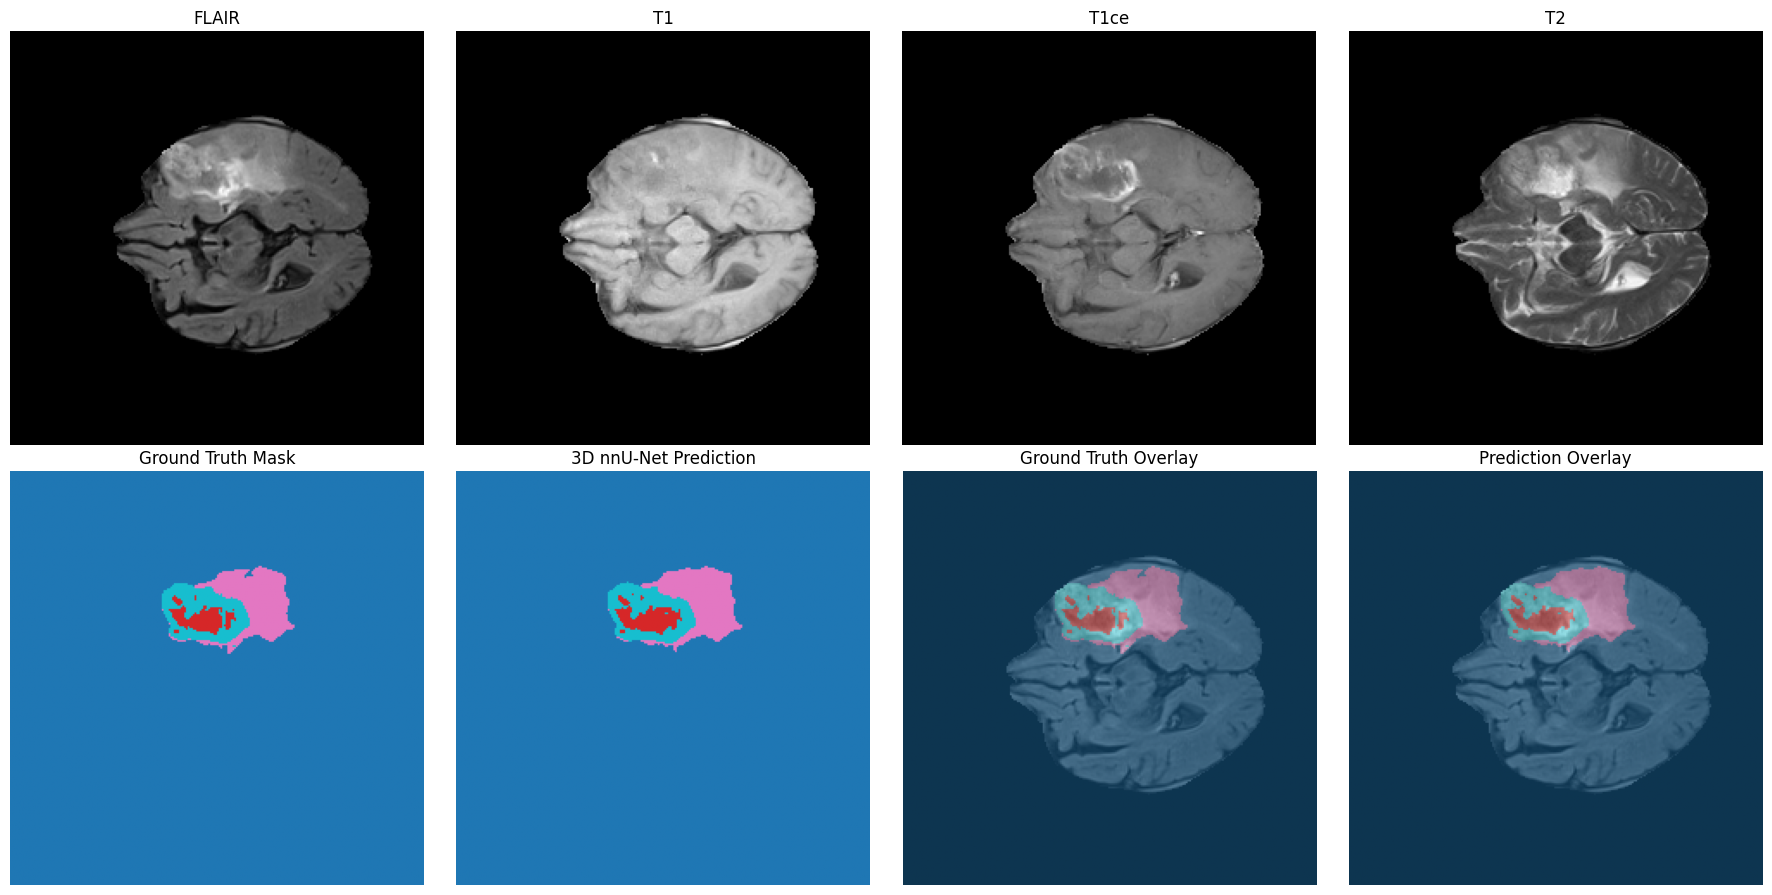

In [ ]:
import matplotlib.pyplot as plt

#slide id has the id of the slice. Evey mri modality has 155 slice.
def visualize_3d_nnunet_prediction(patient, slice_idx=None):
    flair_path = os.path.join(imagesTs, f"{patient}_0000.nii.gz")   #path for the flair 000, t1 0001
    t1_path = os.path.join(imagesTs, f"{patient}_0001.nii.gz")
    t1ce_path = os.path.join(imagesTs, f"{patient}_0002.nii.gz")
    t2_path = os.path.join(imagesTs, f"{patient}_0003.nii.gz")

    gt_path = os.path.join(labelsTs, f"{patient}.nii.gz")   #path for the ground truth
    pred_path = os.path.join(PRED_DIR, f"{patient}.nii.gz") #path for the predicted seg

    flair = nib.load(flair_path).get_fdata()
    t1 = nib.load(t1_path).get_fdata()
    t1ce = nib.load(t1ce_path).get_fdata()
    t2 = nib.load(t2_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    #Get all the slices of the ground truth then get tumor slices out of them
    #then if tumor exist in atleast one layer then select middle layer
    #middle layer of tumor is better
    if slice_idx is None:
        tumor_slices = np.where(np.sum(gt > 0, axis=(0, 1)) > 0)[0]
        if len(tumor_slices) > 0:
            slice_idx = tumor_slices[len(tumor_slices) // 2]
            #selects a slice that contains tumor.
        else:
            slice_idx = gt.shape[2] // 2
            #Select middle slice

    #axes boxes
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0, 0].imshow(flair[:, :, slice_idx], cmap="gray")
    axes[0, 0].set_title("FLAIR")
    axes[0, 0].axis("off") #hides the x-axis and y-axis numbers.

    axes[0, 1].imshow(t1[:, :, slice_idx], cmap="gray")
    axes[0, 1].set_title("T1")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(t1ce[:, :, slice_idx], cmap="gray")
    axes[0, 2].set_title("T1ce")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(t2[:, :, slice_idx], cmap="gray")
    axes[0, 3].set_title("T2")
    axes[0, 3].axis("off")

    #tab10 tab10 gives different colors to different label values.
    #vmin 0 to vmax 3 means that there are 4 classes of tumor and it gives consitent colors based on that
    axes[1, 0].imshow(gt[:, :, slice_idx], cmap="tab10", vmin=0, vmax=3)
    axes[1, 0].set_title("Ground Truth Mask")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(pred[:, :, slice_idx], cmap="tab10", vmin=0, vmax=3)
    axes[1, 1].set_title("3D nnU-Net Prediction")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(flair[:, :, slice_idx], cmap="gray")
    axes[1, 2].imshow(gt[:, :, slice_idx], cmap="tab10", alpha=0.45, vmin=0, vmax=3)
    axes[1, 2].set_title("Ground Truth Overlay")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(flair[:, :, slice_idx], cmap="gray")
    axes[1, 3].imshow(pred[:, :, slice_idx], cmap="tab10", alpha=0.45, vmin=0, vmax=3)
    axes[1, 3].set_title("Prediction Overlay")
    axes[1, 3].axis("off")

    plt.tight_layout() #adjusts spacing between all subplots.
    plt.show()


visualize_3d_nnunet_prediction(test_patients[0])

# Compare nnU-Net vs U-Net segmentation performance.

### Performance Comparison: Dice Score and IoU over Epochs

Let's visualize the Dice Score and IoU for both the UNet2D and nnUNet2D models across the training epochs to compare their performance trends.

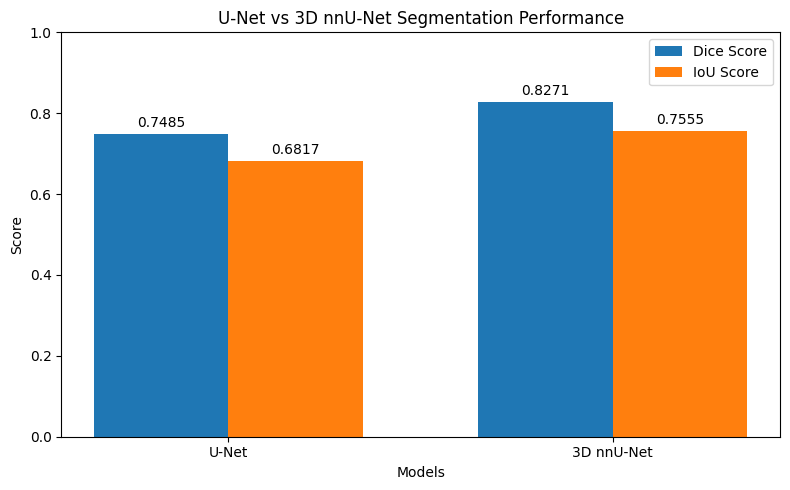

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Helper function: works for both PyTorch tensors and normal float values
def to_float(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().item()
    return float(value)

models = ["U-Net", "3D nnU-Net"]


unet_test_dice= 0.7485
unet_test_iou= 0.6817

# Replace these with your actual U-Net test results
unet_dice = to_float(unet_test_dice)
unet_iou = to_float(unet_test_iou)


# Your official 3D nnU-Net final test results
nnunet_dice = 0.8271
nnunet_iou = 0.7555



dice_scores = [unet_dice, nnunet_dice]
iou_scores = [unet_iou, nnunet_iou]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    dice_scores,
    width,
    label="Dice Score"
)

bars2 = plt.bar(
    x + width/2,
    iou_scores,
    width,
    label="IoU Score"
)

plt.xticks(x, models)
plt.ylabel("Score")
plt.xlabel("Models")
plt.title("U-Net vs 3D nnU-Net Segmentation Performance")
plt.ylim(0, 1.0)
plt.legend()

# Show values on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Summary of Model Comparison

Based on the epoch-wise metrics, we can now provide a final comparison of the UNet2D and nnUNet2D models. Below are the average Dice and IoU scores from the last epoch for a quick summary.

In [ ]:
#Numerical Comparison Table

nnunet_test_dice=0.8271
nnunet_test_iou=0.7555

print("=" * 60)
print("SEGMENTATION PERFORMANCE COMPARISON")
print("=" * 60)

print(f"{'Metric':<15} {'U-Net':<12} {'nnU-Net':<12}")
print("-" * 60)

print(f"{'Dice Score':<15} {unet_test_dice:<12.4f} {nnunet_test_dice:<12.4f}")
print(f"{'IoU Score':<15} {unet_test_iou:<12.4f} {nnunet_test_iou:<12.4f}")

dice_improvement = (
    (nnunet_test_dice - unet_test_dice)
    / unet_test_dice
) * 100

iou_improvement = (
    (nnunet_test_iou - unet_test_iou)
    / unet_test_iou
) * 100

print("-" * 60)
print(f"Dice Improvement : {dice_improvement:.2f}%")
print(f"IoU Improvement  : {iou_improvement:.2f}%")

SEGMENTATION PERFORMANCE COMPARISON
Metric          U-Net        nnU-Net     
------------------------------------------------------------
Dice Score      0.7485       0.8271      
IoU Score       0.6817       0.7555      
------------------------------------------------------------
Dice Improvement : 10.50%
IoU Improvement  : 10.83%


In [ ]:
import os
import torch
import torch.nn.functional as F
import nibabel as nib
import matplotlib.pyplot as plt


def normalize_channel(x):
    mean = x.mean()
    std = x.std()
    return (x - mean) / (std + 1e-8)


def compare_unet_and_nnunet_prediction(
    patient,
    unet_model,
    device,
    imagesTs,
    labelsTs,
    PRED_DIR,
    slice_idx=None,
    unet_input_size=128
):
    # -----------------------------
    # 1. File paths for same patient
    # -----------------------------
    flair_path = os.path.join(imagesTs, f"{patient}_0000.nii.gz")
    t1_path = os.path.join(imagesTs, f"{patient}_0001.nii.gz")
    t1ce_path = os.path.join(imagesTs, f"{patient}_0002.nii.gz")
    t2_path = os.path.join(imagesTs, f"{patient}_0003.nii.gz")

    gt_path = os.path.join(labelsTs, f"{patient}.nii.gz")
    nnunet_pred_path = os.path.join(PRED_DIR, f"{patient}.nii.gz")

    # -----------------------------
    # 2. Load 3D MRI volumes
    # -----------------------------
    flair = nib.load(flair_path).get_fdata()
    t1 = nib.load(t1_path).get_fdata()
    t1ce = nib.load(t1ce_path).get_fdata()
    t2 = nib.load(t2_path).get_fdata()

    gt = nib.load(gt_path).get_fdata().astype(np.uint8)
    nnunet_pred = nib.load(nnunet_pred_path).get_fdata().astype(np.uint8)

    # -----------------------------
    # 3. Select tumor slice automatically
    # -----------------------------
    if slice_idx is None:
        tumor_slices = np.where(np.sum(gt > 0, axis=(0, 1)) > 0)[0]

        if len(tumor_slices) > 0:
            slice_idx = tumor_slices[len(tumor_slices) // 2]
        else:
            slice_idx = gt.shape[2] // 2

    print("Patient:", patient)
    print("Selected slice:", slice_idx)

    # -----------------------------
    # 4. Extract same 2D slice
    # -----------------------------
    flair_slice = flair[:, :, slice_idx]
    t1_slice = t1[:, :, slice_idx]
    t1ce_slice = t1ce[:, :, slice_idx]
    t2_slice = t2[:, :, slice_idx]

    gt_slice = gt[:, :, slice_idx]
    nnunet_slice = nnunet_pred[:, :, slice_idx]

    # -----------------------------
    # 5. Prepare input for custom U-Net
    # -----------------------------
    image_4ch = np.stack([
        normalize_channel(flair_slice),
        normalize_channel(t1_slice),
        normalize_channel(t1ce_slice),
        normalize_channel(t2_slice)
    ], axis=0)

    #converts the NumPy array into a PyTorch tensor.
    #PyTorch models cannot directly take NumPy arrays. They need tensors.
    #convert values into 32-bit floating point numbers.
    #neural networks usually work with float values, not integers.
    #adds one extra dimension at position 0. extra dimension is the batch dimension.
    image_tensor = torch.tensor(image_4ch, dtype=torch.float32).unsqueeze(0).to(device)

    # Resize image for U-Net input size
    #F.interpolate is a PyTorch function used for resizing tensors.
    image_tensor_resized = F.interpolate(
        image_tensor,
        size=(unet_input_size, unet_input_size),
        mode="bilinear",   #resizing method.
        align_corners=False
    )

    # -----------------------------
    # 6. Predict using custom U-Net
    # -----------------------------
    unet_model.eval()

#unet ouput [1, 4, 128, 128], 4 claases and it gives scores
#argmax select high score
    with torch.no_grad():
        unet_output = unet_model(image_tensor_resized)
        unet_pred_small = torch.argmax(unet_output, dim=1).float().unsqueeze(1)

        # Resize U-Net prediction back to original MRI slice size
        #This code resizes the U-Net predicted mask back to the original ground truth slice size,
        # then converts it into a NumPy array for visualization or comparison.
        unet_pred_original = F.interpolate(
            unet_pred_small,
            size=gt_slice.shape,
            mode="nearest"
        )

    #This converts the resized PyTorch tensor into a normal NumPy mask.
    #Remove Dimensions
    unet_pred = unet_pred_original.squeeze().cpu().numpy().astype(np.uint8)

    # -----------------------------
    # 7. Visual comparison
    # -----------------------------
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    axes[0, 0].imshow(flair_slice, cmap="gray")
    axes[0, 0].set_title("Input MRI - FLAIR")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(gt_slice, cmap="tab10", vmin=0, vmax=3)
    axes[0, 1].set_title("Ground Truth Mask")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(unet_pred, cmap="tab10", vmin=0, vmax=3)
    axes[0, 2].set_title("Custom U-Net Prediction")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(nnunet_slice, cmap="tab10", vmin=0, vmax=3)
    axes[0, 3].set_title("Official 3D nnU-Net Prediction")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(flair_slice, cmap="gray")
    axes[1, 0].set_title("Original FLAIR")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(flair_slice, cmap="gray")
    axes[1, 1].imshow(gt_slice, cmap="tab10", alpha=0.45, vmin=0, vmax=3)
    axes[1, 1].set_title("Ground Truth Overlay")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(flair_slice, cmap="gray")
    axes[1, 2].imshow(unet_pred, cmap="tab10", alpha=0.45, vmin=0, vmax=3)
    axes[1, 2].set_title("U-Net Overlay")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(flair_slice, cmap="gray")
    axes[1, 3].imshow(nnunet_slice, cmap="tab10", alpha=0.45, vmin=0, vmax=3)
    axes[1, 3].set_title("3D nnU-Net Overlay")
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

Patient: BraTS2021_00349
Selected slice: 61


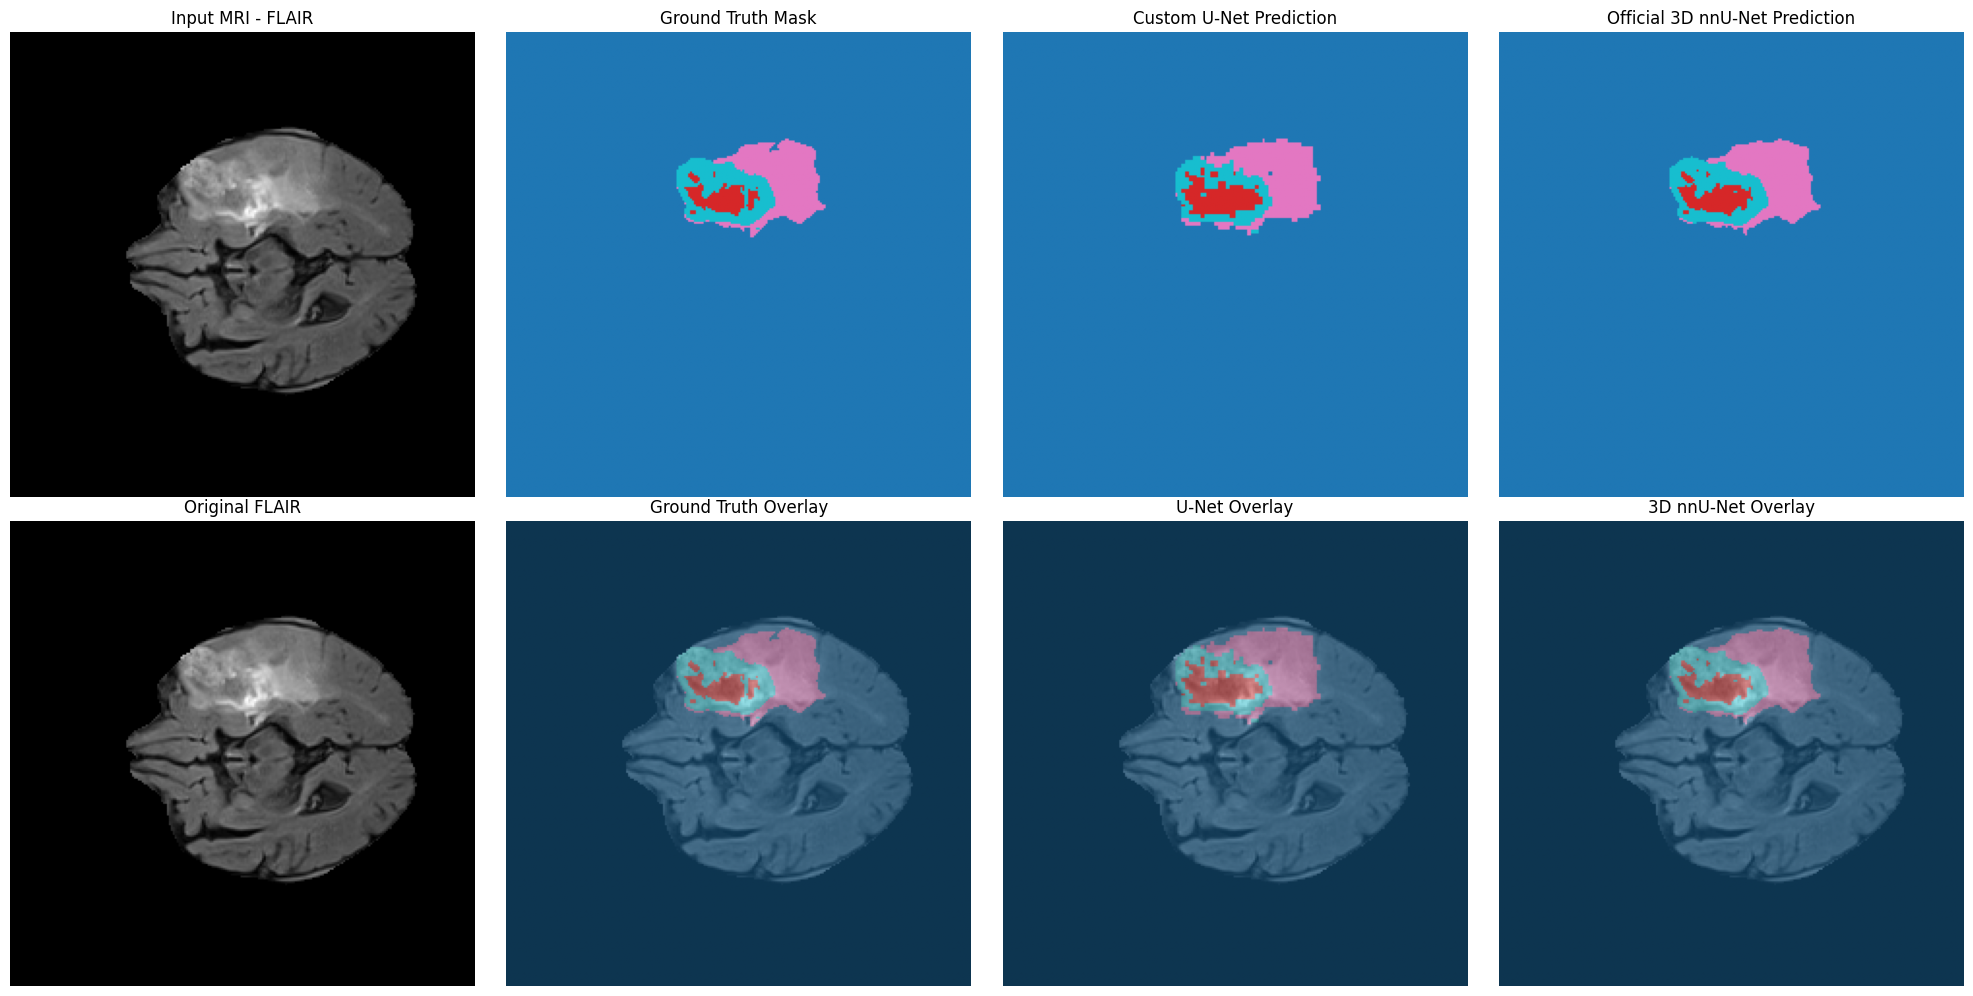

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_unet = UNet2D(in_channels=4, n_classes=4).to(device)

optimizer_unet = torch.optim.AdamW(
    model_unet.parameters(),
    lr=1e-4
)


model_unet.load_state_dict(
    torch.load(
        "/content/best_unet_model.pth",
        map_location=device
    )
)

model_unet.to(device)
model_unet.eval()


compare_unet_and_nnunet_prediction(
    patient=test_patients[0],
    unet_model=model_unet,
    device=device,
    imagesTs=imagesTs,
    labelsTs=labelsTs,
    PRED_DIR="/content/drive/MyDrive/nnUNet_predictions",
    slice_idx=None,
    unet_input_size=128
)

# Wrong U-Net Model

In [ ]:
"""class DoubleConv2D(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(


            The model learns patterns such as:   Each output channel learns something different.

            edges
            tumor boundaries
            bright regions
            textures


             # 4 in_ch MRI input channels, output 64 out_ch output channels, feature maps and kernel size
            # The kernel slides across the image. Kernel examines small regions: and learns useful patterns.


            nn.Conv2d(in_ch, out_ch, 3, padding=1),

            Normalizes activations.

            Benefits:

            faster training
            stable gradients
            better convergence
            nn.BatchNorm2d(out_ch),

            Negative values become zero. Adds non linearty
            nn.ReLU(inplace=True),

            Second Convolution  Further refines extracted features.
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)"""


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_unet = UNet2D(in_channels=4, n_classes=4).to(device)

optimizer_unet = torch.optim.AdamW(
    model_unet.parameters(),
    lr=1e-4
)

print(f"Device: {device}")
print(f"Model params: {sum(p.numel() for p in model_unet.parameters()):,}")





"""Fast convergence
Stable training
Good for deep networks
Weight decay regularization
optimizer will update weights to improve loss and better training, parameters() will return all weights.
"""#lr is learning rate, normally 0.0001 in unet


  #go through all weights and return the in p and then add them and calcultae total number of elements and return the sum with commas